In [1]:
# Importing packages

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

In [2]:
notebook_dir = os.getcwd()
python_dir = os.path.dirname(notebook_dir)

sys.path.append(python_dir)

from validation import walk_forward_validation, plot_walk_forward_results

In [3]:
# Loading and processing the data

# Determining the path to the data
file_dir = os.path.dirname(os.path.realpath('SVM_test.ipynb'))
python_dir = os.path.dirname(file_dir)
data_folder = os.path.join(python_dir, 'Data')
data_file = os.path.join(data_folder, 'combined_data_cleaned_v2.csv')

# Loading the data
df = pd.read_csv(data_file, decimal = ',')

# Changing the datatype
cols = ['OffshoreWindPower',
        'OnshoreWindPower',
        'HydroPower',
        'SolarPower',
        'Biomass',
        'Biogas',
        'Waste',
        'FossilGas',
        'FossilOil',
        'FossilHardCoal',
        'ExchangeGreatBelt',
        'ExchangeGermany',
        'ExchangeSweden',
        'ExchangeNorway',
        'ExchangeNetherlands',
        'WindSpeed',
        'Radiation',
        'DKPrice',
        'DEPrice',
        'NO2Price',
        'SE3Price',
        'SE4Price',
        'OffshoreWindCapacity',
        'OnshoreWindCapacity',
        'SolarPowerCapacity',
        'GrossCon']

power_cols = ['OffshoreWindPower',
        'OnshoreWindPower',
        'HydroPower',
        'SolarPower',
        'Biomass',
        'Biogas',
        'Waste',
        'FossilGas',
        'FossilOil',
        'FossilHardCoal']

df[cols] = df[cols].astype(float)

df['TotalPower'] = df[power_cols].sum(axis=1)

date_format = '%Y-%m-%d %H:%M:%S'

# Saving datetime format
temp_list = []
for i in list(df["TimeUTC"]):
    n = 19
    j = i[:n]
    k = datetime.strptime(j, date_format)
    temp_list.append(k)
df.insert(0, "Time", temp_list, True)
df = df.drop("TimeUTC", axis = 1)

df['TotalPower_lag1'] = df['TotalPower'].shift(1)  # value from 1 hour ago
df['TotalPower_lag24'] = df['TotalPower'].shift(24)  # value from 24 hours ago
df['Price_lag1'] = df['DKPrice'].shift(1)
df['Price_lag24'] = df['DKPrice'].shift(24)

df = df.dropna()

col = df.pop('DKPrice')
df.insert(0, 'DKPrice', col)

# Filtering for price zone
df_DK1 = df[df['DKZone'] == 'DK1']
df_DK1 = df_DK1.drop('DKZone', axis = 1)
df_DK1.reset_index(drop=True, inplace=True)
df_DK2 = df[df['DKZone'] == 'DK2']
df_DK2 = df_DK2.drop('DKZone', axis = 1)
df_DK2.reset_index(drop=True, inplace=True)

# Splitting between initial train and test set for DK1
DK1_train_set = df_DK1.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK1_train_set.set_index('Time', inplace=True)
DK1_train_set = DK1_train_set.asfreq('h')
DK1_train_set.index = DK1_train_set.index.tz_localize(None)
DK1_test_set = df_DK1.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK1_test_set.set_index('Time', inplace=True)
DK1_test_set = DK1_test_set.asfreq('h')
DK1_test_set.index = DK1_test_set.index.tz_localize(None)

# Printing the shape for training and test date for DK1
print(f"Training data shape (DK1): {DK1_train_set.shape}")
print(f"Test data shape (DK1): {DK1_test_set.shape}")
print(f"Test set fraction (DK1): {len(DK1_test_set)/len(DK1_train_set):.2%}")

# Splitting between initial train and test set for DK2
DK2_train_set = df_DK2.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK2_train_set.set_index('Time', inplace=True)
DK2_train_set = DK2_train_set.asfreq('h')
DK2_train_set.index = DK2_train_set.index.tz_localize(None)
DK2_test_set = df_DK2.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK2_test_set.set_index('Time', inplace=True)
DK2_test_set = DK2_test_set.asfreq('h')
DK2_test_set.index = DK2_test_set.index.tz_localize(None)

# Printing the shape for training and test date for DK2
print(f"Training data shape (DK2): {DK2_train_set.shape}")
print(f"Test data shape (DK2): {DK2_test_set.shape}")
print(f"Test set fraction (DK2): {len(DK2_test_set)/len(DK2_train_set):.2%}")

Training data shape (DK1): (78900, 31)
Test data shape (DK1): (8760, 31)
Test set fraction (DK1): 11.10%
Training data shape (DK2): (78900, 31)
Test data shape (DK2): (8760, 31)
Test set fraction (DK2): 11.10%


In [10]:
# Loading and processing the data

# Determining the path to the data
file_dir = os.path.dirname(os.path.realpath('SVM_test.ipynb'))
python_dir = os.path.dirname(file_dir)
data_folder = os.path.join(python_dir, 'Data')
data_file = os.path.join(data_folder, 'combined_data_cleaned_v2.csv')

# Loading the data
df = pd.read_csv(data_file, decimal = ',')

# Changing the datatype
cols = ['OffshoreWindPower',
        'OnshoreWindPower',
        'HydroPower',
        'SolarPower',
        'Biomass',
        'Biogas',
        'Waste',
        'FossilGas',
        'FossilOil',
        'FossilHardCoal',
        'ExchangeGreatBelt',
        'ExchangeGermany',
        'ExchangeSweden',
        'ExchangeNorway',
        'ExchangeNetherlands',
        'WindSpeed',
        'Radiation',
        'DKPrice',
        'DEPrice',
        'NO2Price',
        'SE3Price',
        'SE4Price',
        'OffshoreWindCapacity',
        'OnshoreWindCapacity',
        'SolarPowerCapacity',
        'GrossCon']

power_cols = ['OffshoreWindPower',
        'OnshoreWindPower',
        'HydroPower',
        'SolarPower',
        'Biomass',
        'Biogas',
        'Waste',
        'FossilGas',
        'FossilOil',
        'FossilHardCoal']

df[cols] = df[cols].astype(float)

df['TotalPower'] = df[power_cols].sum(axis=1)

date_format = '%Y-%m-%d %H:%M:%S'

# Saving datetime format
temp_list = []
for i in list(df["TimeUTC"]):
    n = 19
    j = i[:n]
    k = datetime.strptime(j, date_format)
    temp_list.append(k)
df.insert(0, "Time", temp_list, True)
df = df.drop("TimeUTC", axis = 1)

df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['Day'] = df['Time'].dt.day
df['Hour'] = df['Time'].dt.hour

df['TotalPower_lag1'] = df['TotalPower'].shift(1)  # value from 1 hour ago
df['TotalPower_lag24'] = df['TotalPower'].shift(24)  # value from 24 hours ago
df['Price_lag1'] = df['DKPrice'].shift(1)
df['Price_lag24'] = df['DKPrice'].shift(24)

df = df.dropna()

col = df.pop('DKPrice')
df.insert(0, 'DKPrice', col)

# Filtering for price zone
df_DK1 = df[df['DKZone'] == 'DK1']
df_DK1 = df_DK1.drop('DKZone', axis = 1)
df_DK1.reset_index(drop=True, inplace=True)
df_DK2 = df[df['DKZone'] == 'DK2']
df_DK2 = df_DK2.drop('DKZone', axis = 1)
df_DK2.reset_index(drop=True, inplace=True)

# Splitting between initial train and test set for DK1
DK1_train_set = df_DK1.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK1_train_set = DK1_train_set.drop('Time', axis = 1)
DK1_test_set = df_DK1.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK1_test_set = DK1_test_set.drop('Time', axis = 1)

# Printing the shape for training and test date for DK1
print(f"Training data shape (DK1): {DK1_train_set.shape}")
print(f"Test data shape (DK1): {DK1_test_set.shape}")
print(f"Test set fraction (DK1): {len(DK1_test_set)/len(DK1_train_set):.2%}")

# Splitting between initial train and test set for DK2
DK2_train_set = df_DK2.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK2_train_set = DK2_train_set.drop('Time', axis = 1)
DK2_test_set = df_DK2.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK2_test_set = DK2_test_set.drop('Time', axis = 1)

# Printing the shape for training and test date for DK2
print(f"Training data shape (DK2): {DK2_train_set.shape}")
print(f"Test data shape (DK2): {DK2_test_set.shape}")
print(f"Test set fraction (DK2): {len(DK2_test_set)/len(DK2_train_set):.2%}")

Training data shape (DK1): (78900, 35)
Test data shape (DK1): (8760, 35)
Test set fraction (DK1): 11.10%
Training data shape (DK2): (78900, 35)
Test data shape (DK2): (8760, 35)
Test set fraction (DK2): 11.10%


In [5]:
def make_XGB_predict_fn(forecast_horizon):
    def predict_fn(train_data):

        X_train = train_data.iloc[:, 1:]  # all columns except target
        y_train = train_data.iloc[:, 0]   # target column

        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict autoregressively with frozen exogenous features
        last_row = X_train.iloc[-1:].copy()
        predictions = []

        for _ in range(forecast_horizon):
            next_val = model.predict(last_row)[0]
            predictions.append(next_val)
            
            # Update lagged price columns with predicted value
            if 'Price_lag1' in last_row.columns:
                last_row['Price_lag1'] = next_val
            if 'Price_lag24' in last_row.columns:
                last_row['Price_lag24'] = next_val  # simplification
            # All other features (wind, solar, capacity) stay frozen

        return np.array(predictions)
    return predict_fn

In [9]:
def XGB_hyperparameter_predict_Fn(forecast_horizon):
    # Hyperparameters are determined based on the performance during the first fold
    # All following folds utilize the parameters determined as being the best from the first fold

    best_params = [None]

    def predict_fn(train_data):

        X_train = train_data.iloc[:, 1:]  # all columns except target
        y_train = train_data.iloc[:, 0]   # target column

        if best_params[0] is None:

            # Using TimeSeriesSplit for cross validation within the training data alone
            tscv = TimeSeriesSplit(n_splits = 5)

            param_grid = {
                'max_depth': [3, 6, 9],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0],
                'colsample_bytree': [0.8, 1.0]
            }

            model = XGBRegressor()

            search = RandomizedSearchCV(
                model,
                param_grid,
                n_iter = 20, # Number of random combinations the model will try
                cv = tscv,
                scoring = 'neg_root_mean_squared_error',
                n_jobs = -1,
                random_state = 42
            )
            search.fit(X_train, y_train)
            best_params[0] = search.best_params_
            print(f"   Best params: {best_params[0]}")
            model = search.best_estimator_

        else:
            print("  Reusing best params from first fold...")
            model = XGBRegressor(**best_params[0])
            model.fit(X_train, y_train)

        # Predict autoregressively with frozen exogenous features
        last_row = X_train.iloc[-1:].copy()
        predictions = []

        for _ in range(forecast_horizon):
            next_val = model.predict(last_row)[0]
            predictions.append(next_val)
            
            # Update lagged price columns with predicted value
            if 'Price_lag1' in last_row.columns:
                last_row['Price_lag1'] = next_val
            if 'Price_lag24' in last_row.columns:
                last_row['Price_lag24'] = next_val  # simplification
            # All other features (wind, solar, capacity) stay frozen

        return np.array(predictions)
    return predict_fn

In [7]:
# Hyperparameter tuning using the full training set set

X_train_full = DK1_train_set.iloc[:, 1:]
y_train_full = DK1_train_set.iloc[:, 0]

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
search.fit(X_train_full, y_train_full)
best_params = search.best_params_
print(f"Best params: {best_params}")


# SVM prediction function using the parameters from the hyperparameter tuning
def make_XGB_tuned_predict_fn(forecast_horizon, best_params):
    def predict_fn(train_data):
        X_train = train_data.iloc[:, 1:]
        y_train = train_data.iloc[:, 0]

        model = XGBRegressor(**best_params)
        model.fit(X_train, y_train)

        last_row = X_train.iloc[-1:].copy()
        predictions = []

        for _ in range(forecast_horizon):
            next_val = model.predict(last_row)[0]
            predictions.append(next_val)

            if 'Price_lag1' in last_row.columns:
                last_row['Price_lag1'] = next_val
            if 'Price_lag24' in last_row.columns:
                last_row['Price_lag24'] = next_val

        return np.array(predictions)
    return predict_fn


# Running cross validation using the new SVM prediction function and best parameters
svm_tuned_predict = make_XGB_tuned_predict_fn(forecast_horizon=168, best_params=best_params)

results_svm_tuned_DK1 = walk_forward_validation(
    data_series=DK1_train_set,
    predict_fn=svm_tuned_predict,
    training_window=8760,
    forecast_horizon=168,
    expanding=False
)

predictions_tuned_DK1, actuals_tuned_DK1, fold_rmse_tuned_DK1, fold_mae_tuned_DK1, fold_mape_tuned_DK1 = results_svm_tuned_DK1

Best params: {'subsample': 1.0, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Total folds: 416
Training window: 8760 hours
Forecast horizon: 168 hours
Mode: Sliding window

Fold 1/416
  Fold RMSE: 80.06, MAE: 52.43, MAPE: 26.78

Fold 2/416
  Fold RMSE: 49.06, MAE: 21.62, MAPE: 13.09

Fold 3/416
  Fold RMSE: 87.53, MAE: 34.38, MAPE: 11.21

Fold 4/416
  Fold RMSE: 29.38, MAE: 15.65, MAPE: 6.42

Fold 5/416
  Fold RMSE: 30.29, MAE: 19.17, MAPE: 8.16

Fold 6/416
  Fold RMSE: 50.69, MAE: 20.56, MAPE: 6.95

Fold 7/416
  Fold RMSE: 50.40, MAE: 25.59, MAPE: 9.51

Fold 8/416
  Fold RMSE: 105.47, MAE: 59.75, MAPE: 43.80

Fold 9/416
  Fold RMSE: 59.99, MAE: 35.24, MAPE: 21.01

Fold 10/416
  Fold RMSE: 67.56, MAE: 41.01, MAPE: 20.36

Fold 11/416
  Fold RMSE: 61.24, MAE: 35.28, MAPE: 19.93

Fold 12/416
  Fold RMSE: 61.57, MAE: 55.32, MAPE: 30.48

Fold 13/416
  Fold RMSE: 58.49, MAE: 48.33, MAPE: 22.67

Fold 14/416
  Fold RMSE: 75.51, MAE: 48.37, MAPE: 33.29

Fold 15/416
  Fold RMSE:

In [10]:
svm_hyper_predict = XGB_hyperparameter_predict_Fn(forecast_horizon = 168)

results_hyper_svm_DK1 = walk_forward_validation(
    data_series = DK1_train_set,
    predict_fn = svm_hyper_predict,
    training_window = 8760,
    forecast_horizon = 168,
    expanding = False
)

predictions_hyper_DK1, actuals_hyper_DK1, fold_rmse_hyper_DK1, fold_mae_hyper_DK1, fold_mape_hyper_DK1 = results_hyper_svm_DK1

Total folds: 416
Training window: 8760 hours
Forecast horizon: 168 hours
Mode: Sliding window

Fold 1/416
   Best params: {'subsample': 1.0, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold RMSE: 79.09, MAE: 50.14, MAPE: 25.60

Fold 2/416
  Reusing best params from first fold...
  Fold RMSE: 50.20, MAE: 23.32, MAPE: 13.76

Fold 3/416
  Reusing best params from first fold...
  Fold RMSE: 86.59, MAE: 34.60, MAPE: 11.32

Fold 4/416
  Reusing best params from first fold...
  Fold RMSE: 29.92, MAE: 14.23, MAPE: 5.78

Fold 5/416
  Reusing best params from first fold...
  Fold RMSE: 31.81, MAE: 20.05, MAPE: 8.55

Fold 6/416
  Reusing best params from first fold...
  Fold RMSE: 51.24, MAE: 20.90, MAPE: 7.09

Fold 7/416
  Reusing best params from first fold...
  Fold RMSE: 46.88, MAE: 21.62, MAPE: 7.80

Fold 8/416
  Reusing best params from first fold...
  Fold RMSE: 103.97, MAE: 58.86, MAPE: 43.62

Fold 9/416
  Reusing best params from first fold...
  Fold RMSE: 59.42, MAE

In [11]:
svm_predict = make_XGB_predict_fn(forecast_horizon = 168)

results_svm_DK1 = walk_forward_validation(
    data_series = DK1_train_set,
    predict_fn = svm_predict,
    training_window = 8760,
    forecast_horizon = 168,
    expanding = True
)

predictions_DK1, actuals_DK1, fold_rmse_DK1, fold_mae_DK1, fold_mape_hyper_DK1 = results_svm_DK1

Total folds: 417
Training window: 8760 hours
Forecast horizon: 168 hours
Mode: Expanding window

Fold 1/417
  Fold RMSE: 79.12, MAE: 50.22, SMAPE: 25.64

Fold 2/417
  Fold RMSE: 49.80, MAE: 22.49, SMAPE: 13.43

Fold 3/417
  Fold RMSE: 86.23, MAE: 34.90, SMAPE: 11.46

Fold 4/417
  Fold RMSE: 29.65, MAE: 14.54, SMAPE: 5.92

Fold 5/417
  Fold RMSE: 31.64, MAE: 19.92, SMAPE: 8.49

Fold 6/417
  Fold RMSE: 50.67, MAE: 20.54, SMAPE: 6.94

Fold 7/417
  Fold RMSE: 46.26, MAE: 21.13, SMAPE: 7.60

Fold 8/417
  Fold RMSE: 104.98, MAE: 59.39, SMAPE: 43.71

Fold 9/417
  Fold RMSE: 60.33, MAE: 35.02, SMAPE: 20.89

Fold 10/417
  Fold RMSE: 67.47, MAE: 42.13, SMAPE: 20.89

Fold 11/417
  Fold RMSE: 60.50, MAE: 34.25, SMAPE: 19.52

Fold 12/417
  Fold RMSE: 59.58, MAE: 52.09, SMAPE: 28.68

Fold 13/417
  Fold RMSE: 63.40, MAE: 53.68, SMAPE: 25.63

Fold 14/417
  Fold RMSE: 75.51, MAE: 48.81, SMAPE: 33.55

Fold 15/417
  Fold RMSE: 44.17, MAE: 22.77, SMAPE: 14.02

Fold 16/417
  Fold RMSE: 69.71, MAE: 49.88, S

In [11]:
svm_predict = make_XGB_predict_fn(forecast_horizon = 168)

results_svm_DK1 = walk_forward_validation(
    data_series = DK1_train_set,
    predict_fn = svm_predict,
    training_window = 8760,
    forecast_horizon = 168,
    expanding = False
)

predictions_DK1, actuals_DK1, fold_rmse_DK1, fold_mae_DK1, fold_mape_hyper_DK1 = results_svm_DK1

Total folds: 416
Training window: 8760 hours
Forecast horizon: 168 hours
Mode: Sliding window

Fold 1/416
  Fold RMSE: 79.28, MAE: 50.60, MAPE: 25.83

Fold 2/416
  Fold RMSE: 49.14, MAE: 21.66, MAPE: 13.11

Fold 3/416
  Fold RMSE: 86.44, MAE: 34.70, MAPE: 11.37

Fold 4/416
  Fold RMSE: 30.23, MAE: 14.22, MAPE: 5.78

Fold 5/416
  Fold RMSE: 32.17, MAE: 20.33, MAPE: 8.68

Fold 6/416
  Fold RMSE: 51.05, MAE: 20.76, MAPE: 7.03

Fold 7/416
  Fold RMSE: 45.28, MAE: 20.96, MAPE: 7.53

Fold 8/416
  Fold RMSE: 104.13, MAE: 58.92, MAPE: 43.63

Fold 9/416
  Fold RMSE: 59.41, MAE: 35.76, MAPE: 21.29

Fold 10/416
  Fold RMSE: 67.50, MAE: 41.26, MAPE: 20.48

Fold 11/416
  Fold RMSE: 60.96, MAE: 34.88, MAPE: 19.77

Fold 12/416
  Fold RMSE: 60.14, MAE: 53.13, MAPE: 29.25

Fold 13/416
  Fold RMSE: 67.34, MAE: 58.10, MAPE: 28.13

Fold 14/416
  Fold RMSE: 75.52, MAE: 49.97, MAPE: 34.24

Fold 15/416
  Fold RMSE: 44.18, MAE: 22.80, MAPE: 14.03

Fold 16/416
  Fold RMSE: 69.74, MAE: 44.28, MAPE: 27.45

Fold 

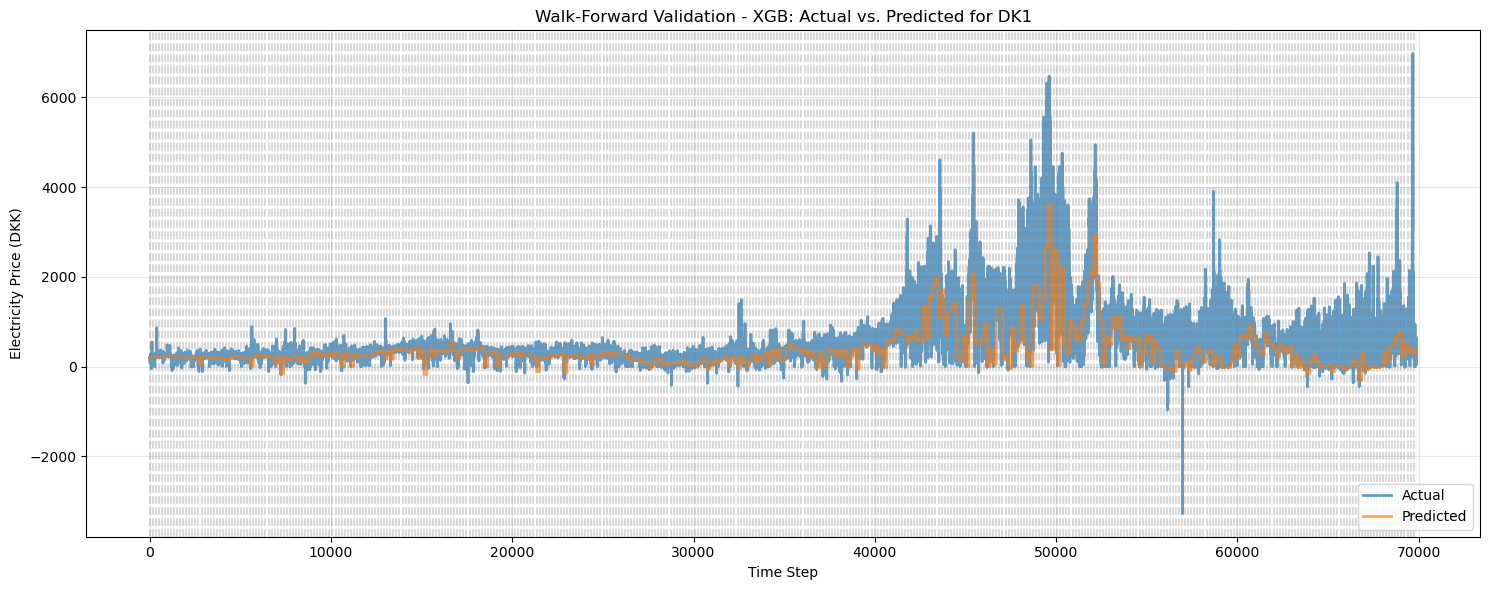

In [12]:
title_DK1 = 'Walk-Forward Validation - XGB: Actual vs. Predicted for DK1'

plot_walk_forward_results(
        predictions_DK1, 
        actuals_DK1, 
        title_DK1)

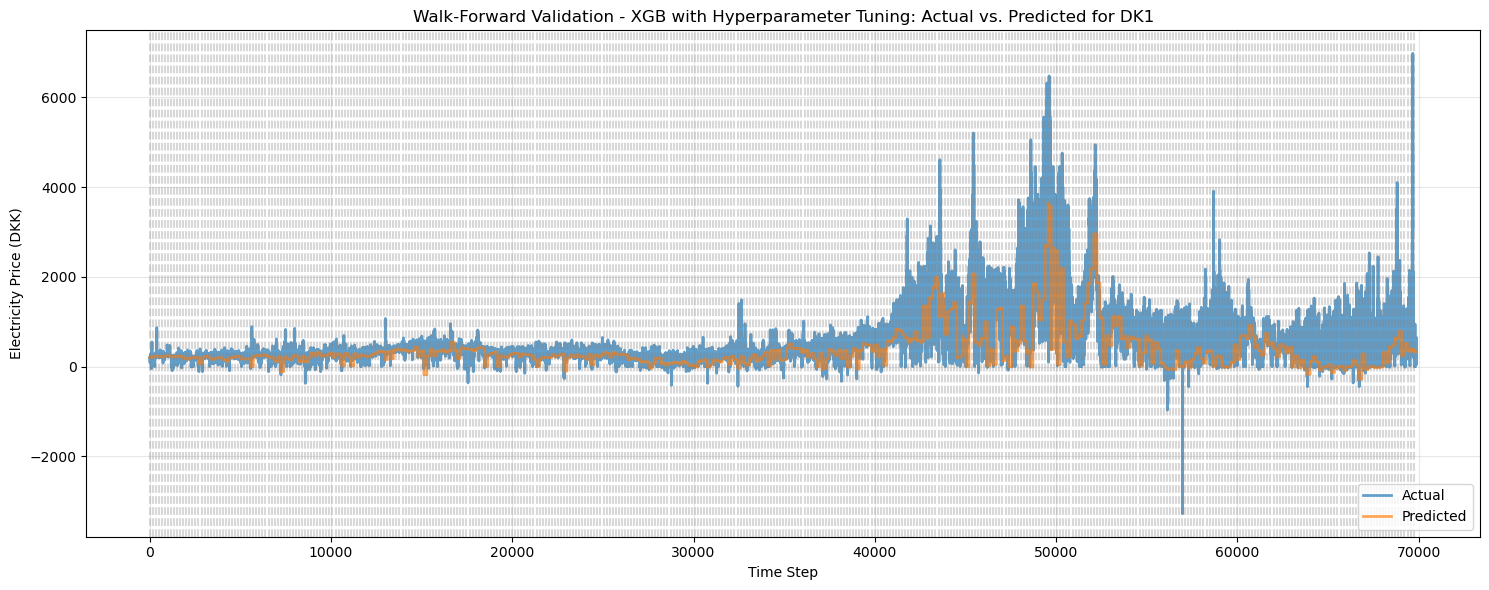

In [13]:
title_hyper_DK1 = 'Walk-Forward Validation - XGB with Hyperparameter Tuning: Actual vs. Predicted for DK1'

plot_walk_forward_results(
        predictions_hyper_DK1, 
        actuals_hyper_DK1, 
        title_hyper_DK1)

In [ ]:
svm_predict = make_XGB_predict_fn(forecast_horizon = 168)

results_svm_DK2 = walk_forward_validation(
    data_series = DK2_train_set,
    predict_fn = svm_predict,
    training_window = 8760,
    forecast_horizon = 168,
    expanding = False
)

predictions_DK2, actuals_DK2, fold_rmse_DK2, fold_mae_DK2, fold_mape_DK2 = results_svm_DK2

In [ ]:
title_DK2 = 'Walk-Forward Validation - XGB: Actual vs. Predicted for DK2'

plot_walk_forward_results(
        predictions_DK2, 
        actuals_DK2, 
        title_DK2)